In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

In [5]:
all_files = glob.glob(os.path.join('/Users/vallurileelasaikrishna/Documents/chess/data/raw_data', "games_20*.csv"))
all_files = sorted(all_files)

In [7]:
carlsen_games = []
for month_file in all_files:
    df_month = pd.read_csv(month_file)

    if "White" in df_month.columns and "Black" in df_month.columns:
        df_month["White"] = df_month["White"].fillna("")
        df_month["Black"] = df_month["Black"].fillna("")

        condition = df_month["White"].str.contains("Carlsen,M", case=False) | df_month[
            "Black"
        ].str.contains("Carlsen,M", case=False)
        carlsen_month = df_month[condition]
        if not carlsen_month.empty:
            carlsen_games.append(carlsen_month)

print([len(each) for each in carlsen_games])

if carlsen_games:
    carlsen_df = pd.concat(carlsen_games, ignore_index=True)
    carlsen_df["Date"] = pd.to_datetime(
        carlsen_df["Date"], format="%Y.%m.%d", errors="coerce"
    )

    carlsen_df = carlsen_df.sort_values(by="Date").reset_index(drop=True)

    print(carlsen_df)
    #carlsen_df.to_csv("magnus_carlsen_games.csv", index=False)

[56, 2, 5, 7, 7, 8, 13, 13, 1, 18, 22, 6, 10, 7, 8, 18, 10, 1, 59, 14, 6, 12, 11, 14, 12, 9, 18, 8, 1, 41, 7, 22, 13, 18, 86, 10, 24, 21, 25, 16, 36, 13, 13, 24, 7, 56, 18, 9, 14, 27, 93, 45, 52, 36, 5, 17, 12, 5, 9, 10, 6, 15, 36, 13, 1, 17, 33, 30, 6, 42, 12, 21, 33, 65, 13, 13, 11, 65, 55, 58, 53, 110, 66, 13, 70, 65, 13, 200, 38, 113, 52, 53, 58, 9, 59, 18, 4, 41, 13, 30, 31, 27, 44, 14, 29, 51, 54, 69, 79, 163, 57, 58, 50, 26, 74, 72, 239, 68, 170, 38, 52, 70, 37, 50, 54, 46, 112, 65, 101, 119, 79, 58, 73, 95, 57, 78, 91, 96, 81, 60, 84, 74, 44, 75, 110, 101, 92, 101, 24, 30, 25, 6]
                       Event        Site       Date           White  \
0          World Rapid Final  Astana KAZ 2012-07-06      Kurnosov,I   
1          World Rapid Final  Astana KAZ 2012-07-06       Carlsen,M   
2          World Rapid Final  Astana KAZ 2012-07-06       Svidler,P   
3          World Rapid Final  Astana KAZ 2012-07-06   Kazhgaleyev,M   
4          World Rapid Final  Astana KAZ 2012-07-0

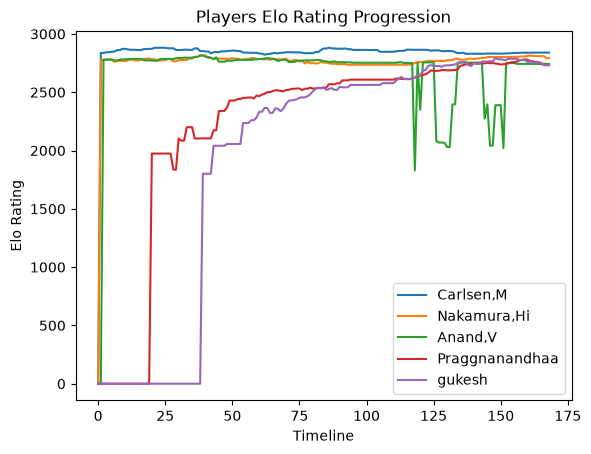

In [10]:
def get_player_elo(games, pre, player):
    is_white = games["White"].str.contains(player, case=False, na=False)
    is_black = games["Black"].str.contains(player, case=False, na=False)

    white_rows = games.loc[is_white, ["WhiteElo"]].rename(columns={"WhiteElo": "Elo"})
    black_rows = games.loc[is_black, ["BlackElo"]].rename(columns={"BlackElo": "Elo"})

    player_elo_df = pd.concat([white_rows, black_rows], ignore_index=True).dropna()
    player_elo = player_elo_df["Elo"].unique()

    if player_elo.size:
        return np.mean(player_elo)
    else:
        return pre


def elo_plot(players):
    for player in players:
        pre = 0
        elos = []
        for file in all_files:
            game = pd.read_csv(file)
            pre = get_player_elo(game, pre, player)
            elos.append(pre)
        player_elo_df = pd.DataFrame(elos, columns=["Elo"])

        plt.plot(player_elo_df, label=player)
    plt.legend()
    plt.xlabel("Timeline")
    plt.ylabel("Elo Rating")
    plt.title("Players Elo Rating Progression")
    plt.show()


elo_plot(["Carlsen,M", "Nakamura,Hi", "Anand,V", "Praggnanandhaa", "gukesh"])